In [1]:
from os import path
import numpy as np
import pandas as pd
import m2stitch
import os
import cv2
import tifffile
import imageio
import matplotlib.pyplot as plt
from skimage.transform import resize
from skimage import exposure
from skimage.feature import match_template
import glob
import re

In [2]:
BASE = ("/path/to/Image")

In [3]:
CHANNEL = "C3" # Choose one of the channels
TIMEPOINT = "T0001"
ZPLANE = "Z001"

In [4]:
ROWS = 39
COLS = 18
OVERLAP = 0.1075
SERPENTINE = False 

In [11]:
OUT = "/path/to/save/SGs_stitched.npy"

In [6]:
# building the file list in field order
field_dirs = sorted(
    glob.glob(os.path.join(BASE, "Field*")),
    key=lambda p: int(re.search(r"Field(\d+)", p).group(1)),
)
print(f"found {len(field_dirs)} field directories")

files = []
for d in field_dirs:
    hits = glob.glob(os.path.join(d, f"*{TIMEPOINT}{ZPLANE}{CHANNEL}.tif"))
    if len(hits) != 1:
        raise RuntimeError(
            f"{os.path.basename(d)}: expected 1 file matching "
            f"{TIMEPOINT}{ZPLANE}{CHANNEL}, found {len(hits)}: {hits}")
    files.append(hits[0])

n = len(files)
print(f"{n} tiles")
print(f"first: {os.path.basename(files[0])}")
print(f"last : {os.path.basename(files[-1])}")

if n != ROWS * COLS:
    raise RuntimeError(
        f"{n} tiles but ROWS*COLS = {ROWS * COLS}. Fix the grid. "
        f"Integer factorisations of {n}: "
        f"{[(a, n // a) for a in range(1, int(n**0.5) + 1) if n % a == 0]}")

# Confirm field number in the filename matches position in the list. If the
# CQ1 numbered fields in a different order than the directories sort, this
# catches it.
for i, f in enumerate(files):
    fnum = int(re.search(r"F(\d+)", os.path.basename(f)).group(1))
    if fnum != i + 1:
        print(f"WARNING: position {i} holds field {fnum} (expected {i+1})")
        break

found 702 field directories
702 tiles
first: W0001F0001T0001Z001C3.tif
last : W0001F0702T0001Z001C3.tif


In [7]:
# Load and compute
probe = tifffile.imread(files[0]).squeeze()
H, W = probe.shape
print(f"tile: {probe.shape} {probe.dtype}, "
      f"stack will be {n * H * W * 2 / 1e9:.1f} GB as uint16")

stack = np.empty((n, H, W), dtype=np.uint16)
for i, f in enumerate(files):
    stack[i] = tifffile.imread(f).squeeze()
    if i % 50 == 0:
        print(f"  loaded {i}/{n}", flush=True)

median_intensity_image = np.empty((H, W), dtype=np.float32)
CHUNK = max(1, 500_000_000 // (n * W * 8))
for y0 in range(0, H, CHUNK):
    y1 = min(y0 + CHUNK, H)
    median_intensity_image[y0:y1] = np.median(stack[:, y0:y1, :], axis=0)

print(f"median image range: {median_intensity_image.min():.0f}-"
      f"{median_intensity_image.max():.0f}")

for i in range(n):
    stack[i] = np.clip(
        stack[i].astype(np.float32) - median_intensity_image, 0, 65535
    ).astype(np.uint16)

tile: (2000, 2000) uint16, stack will be 5.6 GB as uint16
  loaded 0/702
  loaded 50/702
  loaded 100/702
  loaded 150/702
  loaded 200/702
  loaded 250/702
  loaded 300/702
  loaded 350/702
  loaded 400/702
  loaded 450/702
  loaded 500/702
  loaded 550/702
  loaded 600/702
  loaded 650/702
  loaded 700/702
median image range: 101-261


In [8]:
# Replace each tile's overlap bands (4 edges, 2-way median; 4 corners, 4-way) 
# with values computed identically for every tile sharing that region, 
# so later tiles overwrite earlier ones with the same data and the mosaic has no visible seams.
ov = int(round(W * OVERLAP))          
print(f"overlap band: {ov} px")
if ov < 8:
    print("WARNING: very thin overlap. Blending is nearly a no-op and "
          "cross-correlation registration would be unreliable here.")

src = stack.copy()                    
out = stack                           

for i in range(n):
    r, c = divmod(i, COLS)
    has_right = c < COLS - 1
    has_left = c > 0
    has_down = r < ROWS - 1
    has_up = r > 0

    if has_right:
        out[i, :, W-ov:] = np.rint(np.median(
            np.stack([src[i, :, W-ov:], src[i+1, :, :ov]]), axis=0))
    if has_left:
        out[i, :, :ov] = np.rint(np.median(
            np.stack([src[i, :, :ov], src[i-1, :, W-ov:]]), axis=0))
    if has_down:
        out[i, H-ov:, :] = np.rint(np.median(
            np.stack([src[i, H-ov:, :], src[i+COLS, :ov, :]]), axis=0))
    if has_up:
        out[i, :ov, :] = np.rint(np.median(
            np.stack([src[i, :ov, :], src[i-COLS, H-ov:, :]]), axis=0))

    if has_down and has_right:
        out[i, H-ov:, W-ov:] = np.rint(np.median(np.stack([
            src[i,        H-ov:, W-ov:], src[i+1,       H-ov:, :ov],
            src[i+COLS,   :ov,   W-ov:], src[i+COLS+1,  :ov,   :ov]]), axis=0))
    if has_down and has_left:
        out[i, H-ov:, :ov] = np.rint(np.median(np.stack([
            src[i,        H-ov:, :ov],   src[i-1,       H-ov:, W-ov:],
            src[i+COLS,   :ov,   :ov],   src[i+COLS-1,  :ov,   W-ov:]]), axis=0))
    if has_up and has_right:
        out[i, :ov, W-ov:] = np.rint(np.median(np.stack([
            src[i,        :ov,   W-ov:], src[i+1,       :ov,   :ov],
            src[i-COLS,   H-ov:, W-ov:], src[i-COLS+1,  H-ov:, :ov]]), axis=0))
    if has_up and has_left:
        out[i, :ov, :ov] = np.rint(np.median(np.stack([
            src[i,        :ov,   :ov],   src[i-1,       :ov,   W-ov:],
            src[i-COLS,   H-ov:, :ov],   src[i-COLS-1,  H-ov:, W-ov:]]), axis=0))

del src


overlap band: 215 px


In [12]:
# Saving the file
step_y = int(round(H * (1 - OVERLAP)))
step_x = int(round(W * (1 - OVERLAP)))

positions = []
for i in range(n):
    r, c = divmod(i, COLS)
    cc = (COLS - 1 - c) if (SERPENTINE and r % 2 == 1) else c
    positions.append((r * step_y, cc * step_x))

mosaic_h = max(p[0] for p in positions) + H
mosaic_w = max(p[1] for p in positions) + W
print(f"mosaic: {mosaic_h} x {mosaic_w} "
      f"({mosaic_h * mosaic_w * 2 / 1e9:.1f} GB as uint16)")

mosaic = np.zeros((mosaic_h, mosaic_w), dtype=np.uint16)
for i, (y, x) in enumerate(positions):
    mosaic[y:y+H, x:x+W] = out[i]

np.save(OUT, mosaic)
print(f"saved {OUT}")

mosaic: 69830 x 32345 (4.5 GB as uint16)


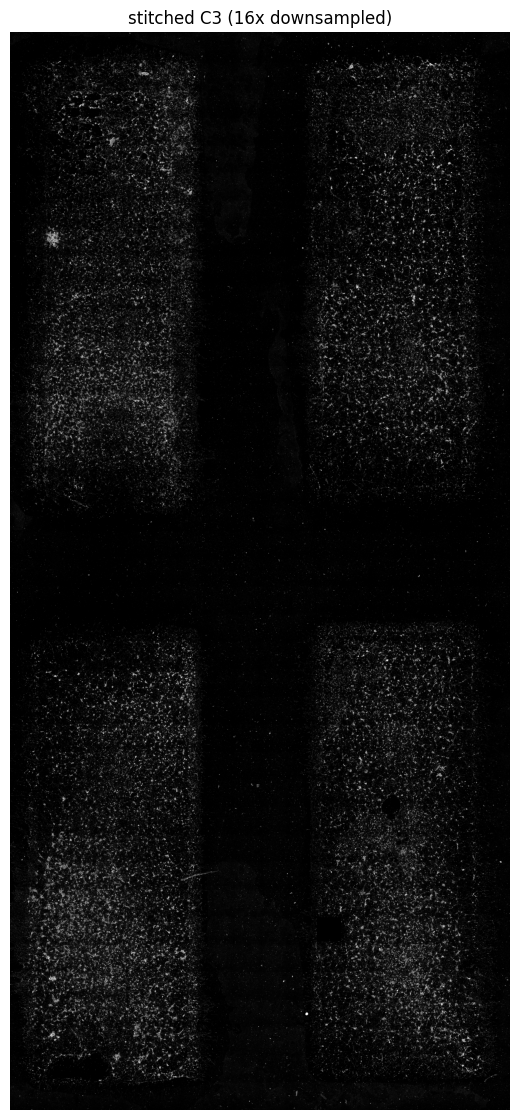

In [13]:
# Viewing the complete stitched image
small = mosaic[::16, ::16]
lo, hi = np.percentile(small, (1, 99.5))
plt.figure(figsize=(14, 14))
plt.imshow(small, cmap="gray", vmin=lo, vmax=hi)
plt.title("stitched C3 (16x downsampled)")
plt.axis("off")
plt.show()

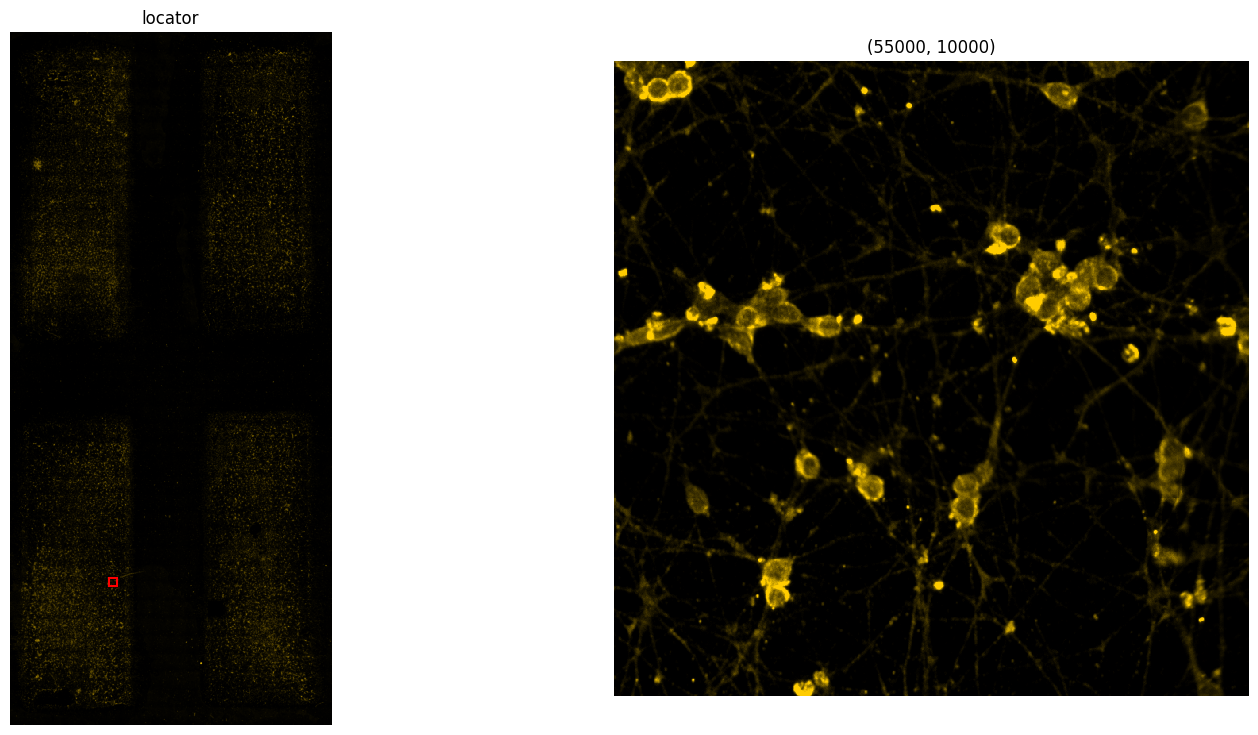

In [14]:
# Adding the ffcc00 color and making a zoomed in image
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("G3BP1", ["black", "#ffcc00"])

Y0, X0, SIZE = 55000, 10000, 800 # can be adjusted to anywhere

crop = mosaic[Y0:Y0+SIZE, X0:X0+SIZE]
lo_c, hi_c = np.percentile(crop, (1, 99.5))
lo_s, hi_s = np.percentile(small[small > 0], (1, 99.5))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

ax1.imshow(small, cmap=cmap, vmin=lo_s, vmax=hi_s)
ax1.add_patch(plt.Rectangle((X0/16, Y0/16), SIZE/16, SIZE/16,
                            ec="red", fc="none", lw=1.5))
ax1.set_title("locator")
ax1.axis("off")

ax2.imshow(crop, cmap=cmap, vmin=lo_c, vmax=hi_c, interpolation="nearest")
ax2.set_title(f"({Y0}, {X0})")
ax2.axis("off")

plt.show()

In [15]:
# Converting npy to ome.tiff since Xenium Explore requires ome.tiff
PIXEL_SIZE = 0.325 
TILE = (1024, 1024)
COMPRESSION = "zlib"
N_LEVELS = 5 

In [16]:
# Writing stitched .npy mosaics as a tiled, compressed, pyramidal BigTIFF OME-TIFF with physical pixel size and channel names embedded
def npy_to_ometiff(npy_path, out_path, channel_names=None,
                   pixel_size=PIXEL_SIZE, n_levels=N_LEVELS):
    if isinstance(npy_path, (list, tuple)):
        arrs = [np.load(p, mmap_mode="r") for p in npy_path]
        shapes = {a.shape for a in arrs}
        if len(shapes) != 1:
            raise ValueError(f"channels differ in size: {shapes}")
        data = np.stack([np.asarray(a) for a in arrs])   # materialises; see note
        axes = "CYX"
    else:
        data = np.load(npy_path, mmap_mode="r")
        axes = "YX"

    print(f"input {data.shape} {data.dtype} "
          f"({data.nbytes / 1e9:.1f} GB uncompressed)")

    metadata = {
        "axes": axes,
        "PhysicalSizeX": pixel_size,
        "PhysicalSizeXUnit": "µm",
        "PhysicalSizeY": pixel_size,
        "PhysicalSizeYUnit": "µm",
    }
    if channel_names:
        metadata["Channel"] = {"Name": list(channel_names)}

    # resolution is in pixels per CENTIMETER
    res = 1e4 / pixel_size
    options = dict(photometric="minisblack", tile=TILE,
                   compression=COMPRESSION, resolutionunit="CENTIMETER")

    with tifffile.TiffWriter(out_path, bigtiff=True) as tif:
        tif.write(data, subifds=n_levels, resolution=(res, res),
                  metadata=metadata, **options)
        for lvl in range(n_levels):
            mag = 2 ** (lvl + 1)
            sub = data[..., ::mag, ::mag]
            print(f"  level {lvl + 1}: {sub.shape}")
            tif.write(sub, subfiletype=1,
                      resolution=(res / mag, res / mag), **options)

    import os
    print(f"wrote {out_path}  ({os.path.getsize(out_path) / 1e9:.2f} GB)")

In [17]:
# Save as ome.tiff file
npy_to_ometiff("/path/to/SGs_stitched.npy", "stitched_SG.ome.tif",
               channel_names=["G3BP1"])

input (69830, 32345) uint16 (4.5 GB uncompressed)
  level 1: (34915, 16173)
  level 2: (17458, 8087)
  level 3: (8729, 4044)
  level 4: (4365, 2022)
  level 5: (2183, 1011)
wrote stitched_SG.ome.tif  (2.33 GB)
